# Federated Learning — DP-SGD Privacy-Utility Trade-off

**Setup:** batch=128, local_epochs=3, rounds=500, C=1.0, δ=1e-5, 10 clients

| Plot | Description |
|------|-------------|
| **Plot 1** | Accuracy curves across rounds — UCI (left) and CASAS (right) side-by-side |
| **Plot 2** | Privacy-utility trade-off — UCI vs CASAS in one graph (FedProx) |
| **Table**  | Full summary: σ, ε, Accuracy, F1, Privacy Level |

In [1]:
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from IPython.display import display

plt.rcParams.update({
    'font.family'        : 'DejaVu Sans',
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.grid'          : True,
    'grid.alpha'         : 0.2,
    'grid.linestyle'     : '--',
    'axes.labelsize'     : 12,
    'axes.titlesize'     : 13,
    'xtick.labelsize'    : 10,
    'ytick.labelsize'    : 10,
    'legend.fontsize'    : 9.5,
    'legend.framealpha'  : 0.92,
    'legend.edgecolor'   : '#cccccc',
    'figure.dpi'         : 140,
})

In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║              CONFIGURATION — edit this cell only            ║
# ╚══════════════════════════════════════════════════════════════╝

RESULTS_DIR = "/home/clara/Research2.0/fyp_fl_smart_home/results"

ARCH      = "cnn"
PARTITION = "non_iid"
ALPHA     = "0.1"
DP_CLIP   = 1.0
DP_DELTA  = 1e-5
LAST_N    = 50       # avg last N rounds for final metric
SMOOTH    = 15       # rolling-avg window (larger = smoother lines)

# ── DP levels — batch=128, rounds=500, epochs=3 ───────────────
# (sigma, target_epsilon, privacy_label)

# UCI HAR (batch=64, n≈735/client, q=0.0871, T=16500 steps)
DP_LEVELS_UCI = [
    (0.0,   None, "No DP"),
    (6.35,  10.0, "Very Weak"),    # ε≈10
    (7.72,   8.0, "Weak"),         # ε≈8
    (9.99,   6.0, "Medium"),       # ε≈6  ← knee
    (14.49,  4.0, "Strong"),       # ε≈4
    (27.95,  2.0, "Very Strong"),  # ε≈2
]

# CASAS Aruba (batch=64, n≈6880/client, q=0.0093, T=160500 steps)
DP_LEVELS_CASAS = [
    (0.0,   None, "No DP"),
    (2.12,  10.0, "Very Weak"),    # ε≈10
    (2.57,   8.0, "Weak"),         # ε≈8
    (3.33,   6.0, "Medium"),       # ε≈6  ← knee
    (4.83,   4.0, "Strong"),       # ε≈4
    (9.31,   2.0, "Very Strong"),  # ε≈2
]

# ── Algorithm for Plot 1 curves ───────────────────────────────
P1_ALGO  = "fedprox"

# ── Algorithm for Plot 2 tradeoff ─────────────────────────────
P2_ALGO  = "fedprox"
P2_METRIC = "accuracy"   # "accuracy" | "f1"

# ── Distinct colors + line styles per privacy level ───────────
# Using both color AND dash pattern → visually distinct even in B&W
LEVEL_STYLES = [
    # (color,     linewidth, linestyle,         marker)
    ("#1a1a2e",  2.6,       "-",                None),   # No DP       — solid dark
    ("#2196F3",  1.8,       "-",                None),   # Very Weak   — solid blue
    ("#4CAF50",  1.8,       "--",               None),   # Weak        — dashed green
    ("#FF9800",  1.8,       "-.",               None),   # Medium      — dash-dot orange
    ("#F44336",  1.8,       ":",                None),   # Strong      — dotted red
    ("#9C27B0",  1.8,       (0, (3, 1, 1, 1)), None),   # Very Strong — dash-dot-dot purple
]

# ── Dataset colors for Plot 2 ─────────────────────────────────
DATASET_STYLES = {
    "uci":   {"color": "#1a7abf", "marker": "s", "ls": "-"},
    "casas": {"color": "#e05c2a", "marker": "^", "ls": "--"},
}

In [3]:
# ── Helpers ───────────────────────────────────────────────────

def _v(val):
    s = str(val)
    return list({s, s.replace('.', '_')})


def find_file(dataset, arch, algo, partition, dp_entry, alpha=ALPHA, clip=DP_CLIP):
    base = f"{dataset}_{arch}_{algo}_{partition}"

    def _search(pats):
        for p in pats:
            hits = glob.glob(p)
            if hits:
                return sorted(hits)[-1]
        return None

    sigma, epsilon, label = dp_entry

    if sigma == 0.0:
        pats = []
        for a in _v(alpha):
            pats += [
                os.path.join(RESULTS_DIR, f"{base}_a{a}_r*_nodp.csv"),
                os.path.join(RESULTS_DIR, f"{base}_a{a}_r*_fl.csv"),
            ]
        pats += [
            os.path.join(RESULTS_DIR, f"{base}_r*_nodp.csv"),
            os.path.join(RESULTS_DIR, f"{base}_r*_fl.csv"),
        ]
    else:
        pats = []
        for a in _v(alpha):
            for c in _v(clip):
                for s in _v(sigma):
                    for e in _v(epsilon):
                        pats.append(os.path.join(
                            RESULTS_DIR,
                            f"{base}_a{a}_r*_dpsgd_C{c}_s{s}_e{e}.csv"
                        ))
        for c in _v(clip):
            for s in _v(sigma):
                for e in _v(epsilon):
                    pats.append(os.path.join(
                        RESULTS_DIR,
                        f"{base}_r*_dpsgd_C{c}_s{s}_e{e}.csv"
                    ))
    return _search(pats)


def dp_levels_for(dataset):
    return DP_LEVELS_UCI if dataset.lower() == "uci" else DP_LEVELS_CASAS


def smooth(series, w):
    return series if w <= 1 else series.rolling(w, min_periods=1, center=True).mean()


def get_col(df, *candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


print("Helpers loaded.")

Helpers loaded.


In [4]:
# ── Debug: verify files ───────────────────────────────────────
print(f"RESULTS_DIR = {RESULTS_DIR}")
print(f"Exists: {os.path.isdir(RESULTS_DIR)}")
print()

for dataset in ["uci", "casas"]:
    dp_levels = dp_levels_for(dataset)
    print(f"── {dataset.upper()} ──")
    for dp_entry in dp_levels:
        path = find_file(dataset, ARCH, P1_ALGO, PARTITION, dp_entry)
        sigma, epsilon, label = dp_entry
        tag  = f"ε={epsilon}" if sigma > 0 else "No DP"
        stat = "OK  " + os.path.basename(path) if path else "NOT FOUND"
        print(f"  [{P1_ALGO:10s}] {label:12s} ({tag:<6})  {stat}")
    print()

print("All CSVs in RESULTS_DIR:")
for f in sorted(glob.glob(os.path.join(RESULTS_DIR, "*.csv"))):
    print(" ", os.path.basename(f))

RESULTS_DIR = /home/clara/Research2.0/fyp_fl_smart_home/results
Exists: True

── UCI ──
  [fedprox   ] No DP        (No DP )  OK  uci_cnn_fedprox_non_iid_a0.1_r500_nodp.csv
  [fedprox   ] Very Weak    (ε=10.0)  OK  uci_cnn_fedprox_non_iid_a0.1_r500_dpsgd_C1.0_s6.35_e10.0.csv
  [fedprox   ] Weak         (ε=8.0 )  OK  uci_cnn_fedprox_non_iid_a0.1_r500_dpsgd_C1.0_s7.72_e8.0.csv
  [fedprox   ] Medium       (ε=6.0 )  OK  uci_cnn_fedprox_non_iid_a0.1_r500_dpsgd_C1.0_s9.99_e6.0.csv
  [fedprox   ] Strong       (ε=4.0 )  OK  uci_cnn_fedprox_non_iid_a0.1_r500_dpsgd_C1.0_s14.49_e4.0.csv
  [fedprox   ] Very Strong  (ε=2.0 )  OK  uci_cnn_fedprox_non_iid_a0.1_r500_dpsgd_C1.0_s27.95_e2.0.csv

── CASAS ──
  [fedprox   ] No DP        (No DP )  OK  casas_cnn_fedprox_non_iid_a0.1_r500_nodp.csv
  [fedprox   ] Very Weak    (ε=10.0)  OK  casas_cnn_fedprox_non_iid_a0.1_r500_dpsgd_C1.0_s2.12_e10.0.csv
  [fedprox   ] Weak         (ε=8.0 )  OK  casas_cnn_fedprox_non_iid_a0.1_r500_dpsgd_C1.0_s2.57_e8.0.csv
  [fe

## Plot 1 — Accuracy Curves: UCI (left) vs CASAS (right)

Saved → plot1_uci_casas_cnn_fedprox_acc_curves.png


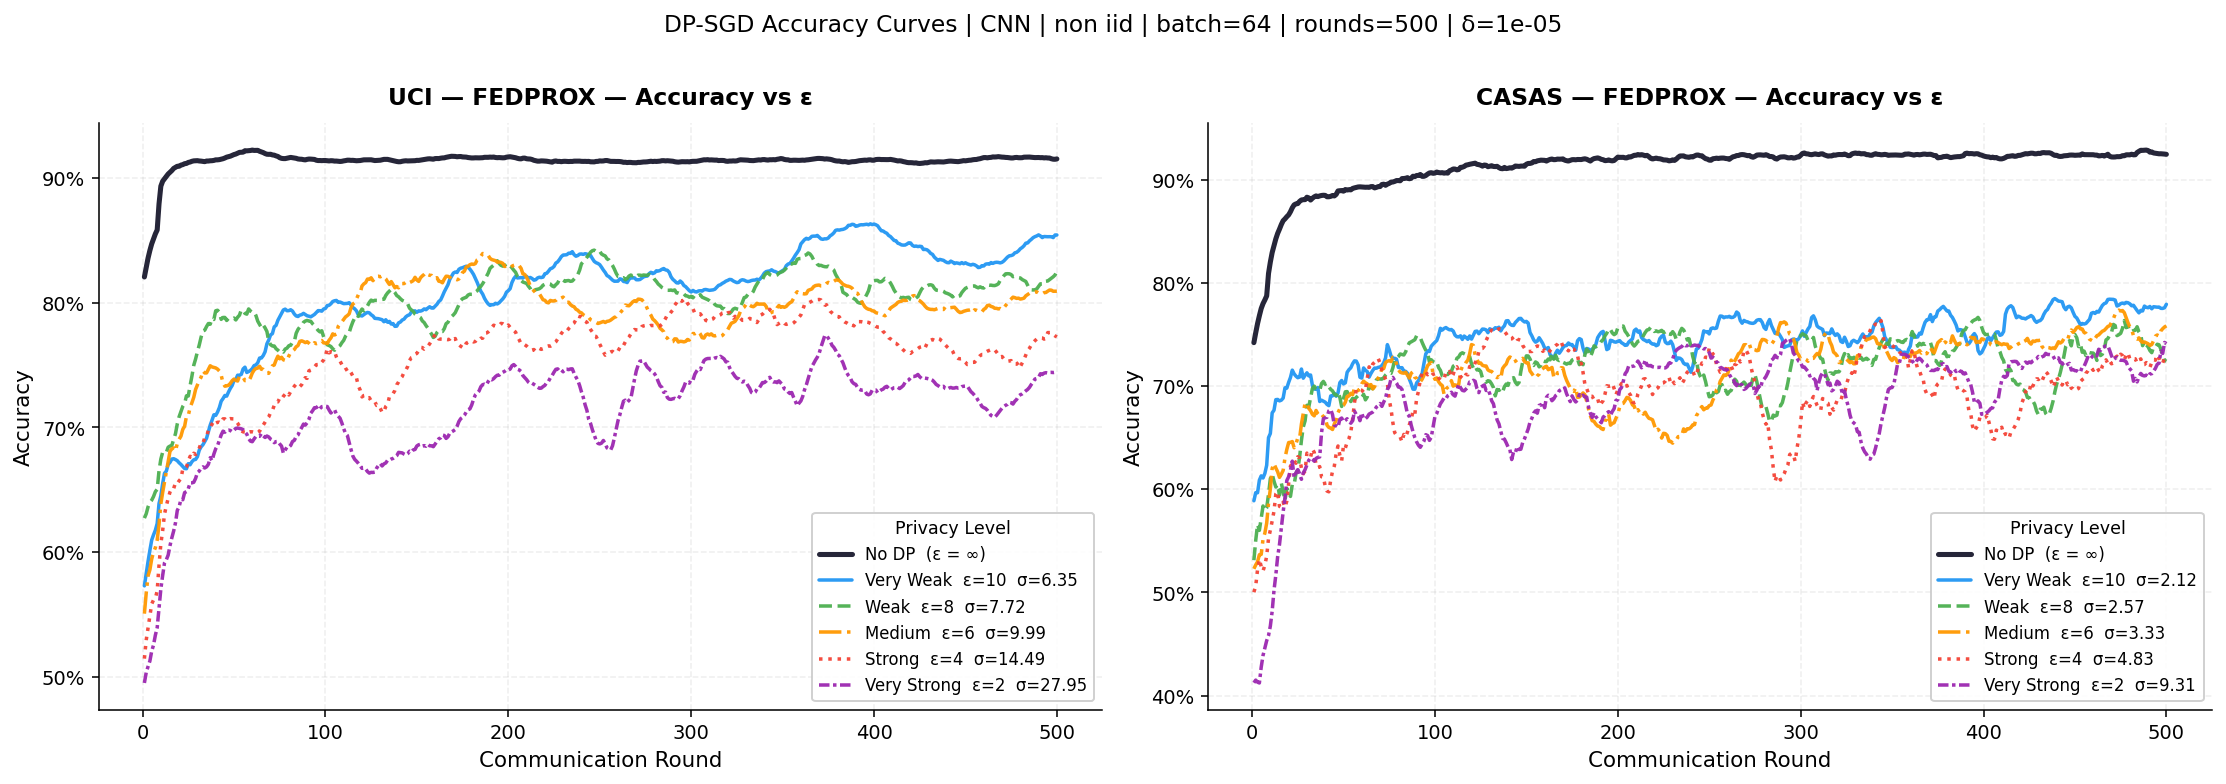

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

for ax, dataset in zip(axes, ["uci", "casas"]):
    dp_levels = dp_levels_for(dataset)
    plotted, missing = 0, []

    for i, dp_entry in enumerate(dp_levels):
        sigma, epsilon, label = dp_entry
        path = find_file(dataset, ARCH, P1_ALGO, PARTITION, dp_entry)
        if path is None:
            missing.append(f"{label}")
            continue

        df  = pd.read_csv(path)
        col = get_col(df, "accuracy", "acc")
        if col is None:
            continue

        color, lw, ls, _ = LEVEL_STYLES[i % len(LEVEL_STYLES)]

        # Label: show ε and σ clearly
        if sigma == 0.0:
            lbl = "No DP  (ε = ∞)"
        else:
            lbl = f"{label}  ε={epsilon:.0f}  σ={sigma}"

        series = smooth(df[col], SMOOTH)

        ax.plot(
            df["round"], series,
            color=color, lw=lw, ls=ls,
            label=lbl, alpha=0.95,
            solid_capstyle="round",
        )
        plotted += 1

    if plotted == 0:
        ax.text(0.5, 0.5, "No data found", ha="center", va="center",
                transform=ax.transAxes, fontsize=12, color="grey")
    else:
        ax.set_xlabel("Communication Round", fontsize=11)
        ax.set_ylabel("Accuracy", fontsize=11)
        ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0))
        ax.set_title(
            f"{dataset.upper()} — {P1_ALGO.upper()} — Accuracy vs ε",
            fontsize=12, fontweight="bold", pad=10
        )
        # Legend inside, sorted: No DP first (highest), Very Strong last (lowest)
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles, labels,
            loc="lower right",
            title="Privacy Level",
            title_fontsize=9,
            fontsize=8.5,
            framealpha=0.92,
            edgecolor="#cccccc",
        )
        if missing:
            ax.text(0.02, 0.02, f"Missing: {', '.join(missing)}",
                    transform=ax.transAxes, fontsize=7.5, color="#e53e3e")

plt.suptitle(
    f"DP-SGD Accuracy Curves | {ARCH.upper()} | {PARTITION.replace('_',' ')} | "
    f"batch=64 | rounds=500 | δ={DP_DELTA}",
    fontsize=12, y=1.01
)
plt.tight_layout()
out1 = f"plot1_uci_casas_{ARCH}_{P1_ALGO}_acc_curves.png"
plt.savefig(out1, bbox_inches="tight", dpi=150)
print(f"Saved → {out1}")
plt.show()

## Plot 2 — Privacy-Utility Trade-off: UCI vs CASAS (one graph)

Saved → plot2_uci_vs_casas_cnn_fedprox_tradeoff.png


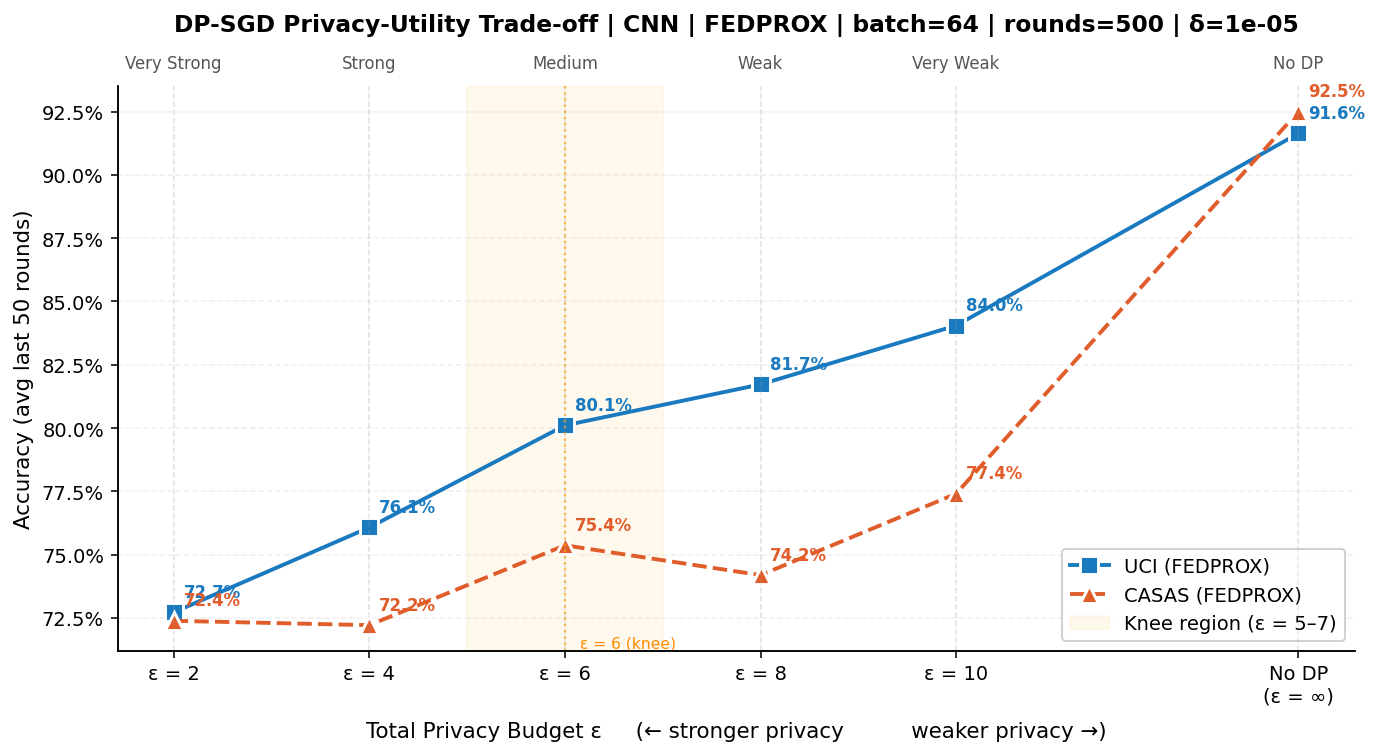

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.5))
missing2 = []

# Both datasets share the same ε values → use ε as x-axis
# No DP placed at far right with a gap
all_eps     = sorted({e for d in [DP_LEVELS_UCI, DP_LEVELS_CASAS] for _, e, _ in d if e is not None})
nodp_pos    = max(all_eps) * 1.35
eps_to_pos  = {e: e for e in all_eps}
eps_to_pos[None] = nodp_pos

for dataset in ["uci", "casas"]:
    dp_levels = dp_levels_for(dataset)
    style     = DATASET_STYLES[dataset]
    xs, ys    = [], []

    for dp_entry in dp_levels:
        sigma, epsilon, label = dp_entry
        path = find_file(dataset, ARCH, P2_ALGO, PARTITION, dp_entry)
        if path is None:
            missing2.append(f"{dataset.upper()}/{label}")
            continue
        df    = pd.read_csv(path)
        col   = P2_METRIC if P2_METRIC in df.columns else "accuracy"
        final = df[col].iloc[-LAST_N:].mean()
        xs.append(eps_to_pos[epsilon])
        ys.append(final)

    if xs:
        pairs = sorted(zip(xs, ys))
        xp    = [p[0] for p in pairs]
        yp    = [p[1] for p in pairs]

        ax.plot(
            xp, yp,
            color=style["color"],
            marker=style["marker"],
            ls=style["ls"],
            lw=2.0, ms=9,
            markeredgewidth=1.5,
            markeredgecolor="white",
            label=f"{dataset.upper()} ({P2_ALGO.upper()})",
        )
        # Annotate each point with accuracy %
        for x, y in zip(xp, yp):
            ax.annotate(
                f"{y*100:.1f}%",
                xy=(x, y),
                xytext=(5, 8),
                textcoords="offset points",
                fontsize=8.5,
                color=style["color"],
                fontweight="bold",
            )

# Shade knee region
ax.axvspan(5, 7, alpha=0.07, color="orange", label="Knee region (ε = 5–7)")
ax.axvline(x=6, color="orange", lw=1.2, ls=":", alpha=0.7)
ax.text(6.1, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0.3,
        " ε = 6 (knee)", fontsize=8, color="darkorange", va="bottom")

# X-axis: ε values + No DP
tick_pos = sorted(all_eps) + [nodp_pos]
tick_lbl = [f"ε = {int(e)}" for e in sorted(all_eps)] + ["No DP\n(ε = ∞)"]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lbl, fontsize=10)

# Top x-axis: privacy level labels
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(tick_pos)
eps_to_label = {e: lbl for _, e, lbl in DP_LEVELS_UCI}
eps_to_label[None] = "No DP"

priv_labels = []
for e in sorted(all_eps):                # ε = 2, 4, 6, 8, 10
    priv_labels.append(eps_to_label.get(e, str(e)))
priv_labels.append(eps_to_label[None])   # No DP at far right

ax2.set_xticklabels(priv_labels, fontsize=8.5, color="#555")
ax2.spines["top"].set_visible(False)
ax2.tick_params(top=False)

metric_label = "Accuracy" if P2_METRIC == "accuracy" else "Macro F1"
ax.set_xlabel(
    "Total Privacy Budget ε     (← stronger privacy          weaker privacy →)",
    fontsize=11, labelpad=8
)
ax.set_ylabel(f"{metric_label} (avg last {LAST_N} rounds)", fontsize=11)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=1))
ax.set_title(
    f"DP-SGD Privacy-Utility Trade-off | {ARCH.upper()} | {P2_ALGO.upper()} | "
    f"batch=64 | rounds=500 | δ={DP_DELTA}",
    fontsize=12, fontweight="bold", pad=12
)
ax.legend(loc="lower right", fontsize=10, framealpha=0.92)

if missing2:
    print(f"[!] Missing: {missing2}")

plt.tight_layout()
out2 = f"plot2_uci_vs_casas_{ARCH}_{P2_ALGO}_tradeoff.png"
plt.savefig(out2, bbox_inches="tight", dpi=150)
print(f"Saved → {out2}")
plt.show()

Saved → plot2b_uci_vs_casas_cnn_fedprox_f1_tradeoff.png


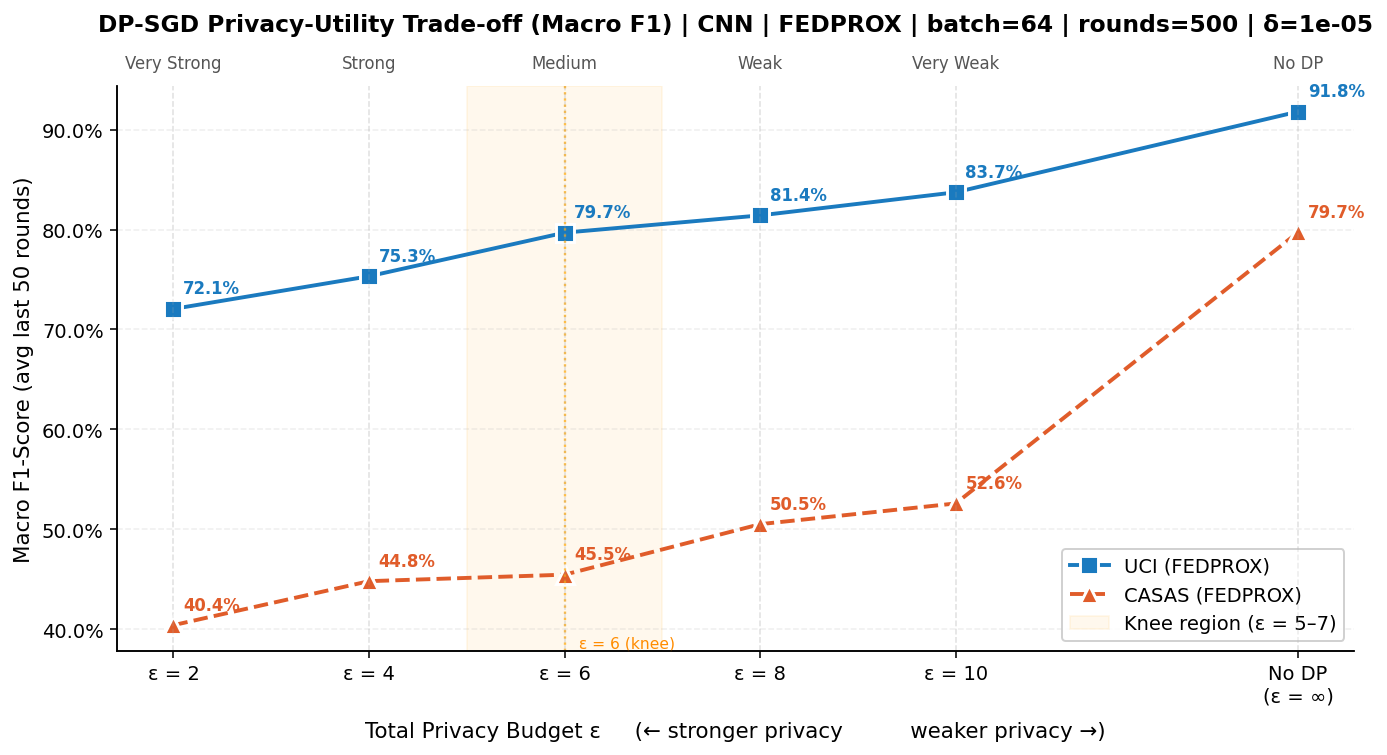

In [7]:
# ── Plot 2b — Privacy-Utility Trade-off: Macro F1 ─────────────

P2_METRIC_F1 = "f1"   # change this if your CSV column name is different

fig, ax = plt.subplots(figsize=(10, 5.5))
missing2b = []

all_eps    = sorted({e for d in [DP_LEVELS_UCI, DP_LEVELS_CASAS] for _, e, _ in d if e is not None})
nodp_pos   = max(all_eps) * 1.35
eps_to_pos = {e: e for e in all_eps}
eps_to_pos[None] = nodp_pos

for dataset in ["uci", "casas"]:
    dp_levels = dp_levels_for(dataset)
    style     = DATASET_STYLES[dataset]
    xs, ys    = [], []

    for dp_entry in dp_levels:
        sigma, epsilon, label = dp_entry
        path = find_file(dataset, ARCH, P2_ALGO, PARTITION, dp_entry)
        if path is None:
            missing2b.append(f"{dataset.upper()}/{label}")
            continue
        df    = pd.read_csv(path)
        col   = P2_METRIC_F1 if P2_METRIC_F1 in df.columns else "accuracy"
        final = df[col].iloc[-LAST_N:].mean()
        xs.append(eps_to_pos[epsilon])
        ys.append(final)

    if xs:
        pairs = sorted(zip(xs, ys))
        xp    = [p[0] for p in pairs]
        yp    = [p[1] for p in pairs]
        ax.plot(
            xp, yp,
            color=style["color"],
            marker=style["marker"],
            ls=style["ls"],
            lw=2.0, ms=9,
            markeredgewidth=1.5,
            markeredgecolor="white",
            label=f"{dataset.upper()} ({P2_ALGO.upper()})",
        )
        for x, y in zip(xp, yp):
            ax.annotate(
                f"{y*100:.1f}%",
                xy=(x, y),
                xytext=(5, 8),
                textcoords="offset points",
                fontsize=8.5,
                color=style["color"],
                fontweight="bold",
            )

ax.axvspan(5, 7, alpha=0.07, color="orange", label="Knee region (ε = 5–7)")
ax.axvline(x=6, color="orange", lw=1.2, ls=":", alpha=0.7)
ax.text(6.1, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0.3,
        " ε = 6 (knee)", fontsize=8, color="darkorange", va="bottom")

tick_pos = sorted(all_eps) + [nodp_pos]
tick_lbl = [f"ε = {int(e)}" for e in sorted(all_eps)] + ["No DP\n(ε = ∞)"]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lbl, fontsize=10)

ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(tick_pos)
eps_to_label = {e: lbl for _, e, lbl in DP_LEVELS_UCI}
eps_to_label[None] = "No DP"
priv_labels = [eps_to_label.get(e, str(e)) for e in sorted(all_eps)] + [eps_to_label[None]]
ax2.set_xticklabels(priv_labels, fontsize=8.5, color="#555")
ax2.spines["top"].set_visible(False)
ax2.tick_params(top=False)

ax.set_xlabel(
    "Total Privacy Budget ε     (← stronger privacy          weaker privacy →)",
    fontsize=11, labelpad=8
)
ax.set_ylabel(f"Macro F1-Score (avg last {LAST_N} rounds)", fontsize=11)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=1))
ax.set_title(
    f"DP-SGD Privacy-Utility Trade-off (Macro F1) | {ARCH.upper()} | {P2_ALGO.upper()} | "
    f"batch=64 | rounds=500 | δ={DP_DELTA}",
    fontsize=12, fontweight="bold", pad=12
)
ax.legend(loc="lower right", fontsize=10, framealpha=0.92)

if missing2b:
    print(f"[!] Missing: {missing2b}")

plt.tight_layout()
out2b = f"plot2b_uci_vs_casas_{ARCH}_{P2_ALGO}_f1_tradeoff.png"
plt.savefig(out2b, bbox_inches="tight", dpi=150)
print(f"Saved → {out2b}")
plt.show()

## Table — Full DP-SGD Summary

In [8]:
TABLE_ALGOS    = ["fedprox"]
TABLE_DATASETS = ["uci", "casas"]

rows = []
for dataset in TABLE_DATASETS:
    dp_levels = dp_levels_for(dataset)
    for algo in TABLE_ALGOS:
        for dp_entry in dp_levels:
            sigma, epsilon, label = dp_entry
            path = find_file(dataset, ARCH, algo, PARTITION, dp_entry)
            if path is None:
                continue
            df   = pd.read_csv(path)
            tail = df.iloc[-LAST_N:]

            c_loss = get_col(tail, "loss")
            c_acc  = get_col(tail, "accuracy", "acc")
            c_f1   = get_col(tail, "f1")
            c_wall = get_col(tail, "fit_wall_s")
            c_down = get_col(tail, "comm_bytes_down")
            c_eps  = get_col(tail, "dp_epsilon", "dp_epsilon_mean")
            c_mem  = get_col(tail, "memory_usage_mb")

            if sigma == 0.0:
                eps_str, sigma_str = "∞", "—"
            else:
                sigma_str = str(sigma)
                if c_eps and tail[c_eps].notna().any():
                    pr = tail[c_eps].dropna().mean()
                    eps_str = f"{epsilon:.0f}  (per-round≈{pr:.3f})"
                else:
                    eps_str = f"{epsilon:.0f}"

            rows.append({
                "Dataset":       dataset.upper(),
                "Algorithm":     algo.upper(),
                "Privacy Level": label,
                "ε (δ=1e-5)":   eps_str,
                "σ":            sigma_str,
                "Accuracy ↑":   f"{tail[c_acc].mean()*100:.2f}%" if c_acc  else "—",
                "F1 (macro) ↑": f"{tail[c_f1].mean()*100:.2f}%"  if c_f1   else "—",
                "Loss ↓":       f"{tail[c_loss].mean():.2f}"      if c_loss else "—",
                "Wall s/rnd":   f"{tail[c_wall].mean():.2f}s"     if c_wall else "—",
                "Comm MB/rnd":  f"{tail[c_down].mean()/1e6:.3f}"  if c_down else "—",
                "Mem MB/rnd": f"{tail[c_mem].mean():.1f} MB" if c_mem else "—",
            })

df_tbl = pd.DataFrame(rows)

LEVEL_BG = {
    "No DP":       "#e8f5e9",
    "Very Weak":   "#e3f2fd",
    "Weak":        "#fff9e6",
    "Medium":      "#fff3e0",
    "Strong":      "#fde8e8",
    "Very Strong": "#f5d5d5",
}

def style_table(df):
    s = df.style
    s = s.apply(
        lambda row: [
            f"background-color: {LEVEL_BG.get(row['Privacy Level'], '')}" 
            if LEVEL_BG.get(row['Privacy Level']) else ""
        ] * len(row),
        axis=1
    )
    s = s.set_table_styles([
        {"selector": "thead th", "props": [
            ("background-color", "#1a1a2e"), ("color", "white"),
            ("font-size", "11px"), ("text-align", "center"),
            ("padding", "8px 12px"), ("border-bottom", "2px solid #4a90d9"),
        ]},
        {"selector": "tbody td", "props": [
            ("font-size", "11px"), ("text-align", "center"),
            ("padding", "6px 12px"), ("border-bottom", "1px solid #e0e0e0"),
        ]},
        {"selector": "tbody tr:hover", "props": [("filter", "brightness(0.95)")]},
        {"selector": "", "props": [("border-collapse", "collapse"), ("width", "100%")]},
    ])
    s = s.hide(axis="index")
    s = s.set_caption(
        f"<b>DP-SGD Privacy-Utility Summary</b> — avg last {LAST_N} rounds | "
        f"C={DP_CLIP} | δ={DP_DELTA} | batch=128 | epochs=3 | rounds=500"
    ).set_table_attributes(
        'style="caption-side:top; font-size:13px; margin-bottom:10px;"'
    )
    return s

print(f"Total rows: {len(rows)}")
display(style_table(df_tbl))
df_tbl.to_csv("dpsgd_summary.csv", index=False)
print("Saved → dpsgd_summary.csv")

Total rows: 12


Dataset,Algorithm,Privacy Level,ε (δ=1e-5),σ,Accuracy ↑,F1 (macro) ↑,Loss ↓,Wall s/rnd,Comm MB/rnd,Mem MB/rnd
UCI,FEDPROX,No DP,∞,—,91.64%,91.81%,1.81,0.33s,0.109,1574.5 MB
UCI,FEDPROX,Very Weak,10 (per-round≈0.270),6.35,84.05%,83.73%,5.46,0.52s,0.109,1538.2 MB
UCI,FEDPROX,Weak,8 (per-round≈0.220),7.72,81.72%,81.42%,6.06,0.52s,0.109,1539.3 MB
UCI,FEDPROX,Medium,6 (per-round≈0.174),9.99,80.10%,79.69%,6.71,0.59s,0.109,1523.7 MB
UCI,FEDPROX,Strong,4 (per-round≈0.137),14.49,76.07%,75.33%,9.69,0.52s,0.109,1539.0 MB
UCI,FEDPROX,Very Strong,2 (per-round≈0.112),27.95,72.72%,72.06%,10.14,0.52s,0.109,1537.1 MB
CASAS,FEDPROX,No DP,∞,—,92.50%,79.72%,0.21,1.64s,0.106,1469.4 MB
CASAS,FEDPROX,Very Weak,10 (per-round≈0.363),2.12,77.40%,52.58%,3.77,3.03s,0.106,1344.9 MB
CASAS,FEDPROX,Weak,8 (per-round≈0.282),2.57,74.19%,50.51%,2.84,2.64s,0.106,1495.0 MB
CASAS,FEDPROX,Medium,6 (per-round≈0.213),3.33,75.37%,45.45%,2.72,2.64s,0.106,1492.5 MB


Saved → dpsgd_summary.csv


---
## Reference: σ ↔ ε Mapping (batch=128, rounds=500, epochs=3)

### UCI HAR (n≈735/client, q=0.174, T=7500 steps)

| Privacy Level | ε | σ | noise/avg (σ/128) | `--dp_noise` |
|---|---|---|---|---|
| No DP | ∞ | — | 0 | *(no --dp)* |
| Very Weak | 10 | 8.6 | 0.067 | `8.6` |
| Weak | 8 | 10.4 | 0.081 | `10.4` |
| **Medium ⭐** | **6** | **13.5** | **0.105** | **`13.5`** |
| Strong | 4 | 19.5 | 0.152 | `19.5` |
| Very Strong | 2 | 37.7 | 0.294 | `37.7` |

### CASAS Aruba (n≈6880/client, q=0.0186, T=79500 steps)

| Privacy Level | ε | σ | noise/avg (σ/128) | `--dp_noise` |
|---|---|---|---|---|
| No DP | ∞ | — | 0 | *(no --dp)* |
| Very Weak | 10 | 3.0 | 0.023 | `3.0` |
| Weak | 8 | 3.6 | 0.028 | `3.6` |
| **Medium ⭐** | **6** | **4.7** | **0.037** | **`4.7`** |
| Strong | 4 | 6.8 | 0.053 | `6.8` |
| Very Strong | 2 | 13.1 | 0.102 | `13.1` |